# Monte Carlo simulace dle Guillochonova článku

Tento notebook ukazuje MC simulaci TDE podle článku Guillochon et al. (2015). Veškeré funkcionality jsem modularizoval do balíčku TDESim, kde jsou stručná vysvětlení v docstrings jednotlivých funkcí. Podrobnější popis výpočtů a odvození je provizorně sepsaný v overleafu.

Nejprve importuji všechny potřebné závislosti:

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import TDESim as tde
from TDESim.config import SimulationParams
from TDESim.utils import rsun_to_rg, msun_to_rg

Vytvoříme generátor náhodných čísel a zadáme společné parametry simulace:

In [7]:
rng = np.random.default_rng(42) # seed 42 pro reprodukovatelnost
Nsim = 1000 # počet běhů simulace
res = 1000 # úhlové rozlišení simulace
e = 0.999 # velká excentricita, pro jednoduchost společná

Začneme generováním hmotností a spinů černé díry:

In [8]:
Mh = 10**rng.uniform(5,8,Nsim)
a = rng.uniform(0,1,Nsim)

Parametry hvězdy generujeme dle článků předepsaných v Guillochonovi:

In [9]:
# (13) from Kroupa, P., Tout, C. A., and Gilmore, G., 
# “The Distribution of Low-Mass Stars in the Galactic Disc”

Mstar = tde.kroupa(0.1,100,Nsim,rng)

# (2) from Tout, C. A., Pols, O. R., Eggleton, P. P., and Han, Z., 
# “Zero-age main-seqence radii and luminosities as analytic functions of mass and metallicity”

Rstar = tde.tout_get_radius(Mstar)

Musíme ještě zkontrolovat, jestli je pro všechny konfigurace IBCO pod Tidal radius, jinak nebude možné vygenerovat vhodné beta. Lze to udělat efektivně s pomocí numpy vektorizace:

In [10]:
while np.any(msun_to_rg((2 - a  + 2 * (1 - a)**(1/2))*Mh, Mh) >= rsun_to_rg(Rstar, Mh) * (Mh/Mstar)**(1/3)):
    # Tato podmínka hledá konfigurace kdy prográdní IBCO (to menší) je nad Tidal radiem
    ind = np.where(msun_to_rg((2 + a  + 2 * (1 + a)**(1/2))*Mh, Mh) >= rsun_to_rg(Rstar, Mh) * (Mh/Mstar)**(1/3))
    Mh[ind] = 10**rng.uniform(5,8, len(ind[0]))
    a[ind] = rng.uniform(0,1, len(ind[0]))
    Mstar[ind] = tde.kroupa(0.1,100,len(ind[0]),rng)
    Rstar[ind] = tde.tout_get_radius(Mstar[ind])

Parametry orbity teď musíme generovat tak, aby byly nad IBCO (ale pod tidal radiem) - pokud nejsou, musíme znovu vylosovat inklinaci a beta.

In [11]:
i = np.empty_like(a)
beta = np.empty_like(a)

for n in range(Nsim):
    check = True
    while check:
        i_sample = rng.uniform(0, np.pi)
        beta_sample = rng.pareto(1) + 1 # musíme přičíst 1 protože původní PDF je Lorax, ne Pareto
        if tde.check_IBCO(beta_sample, i_sample, a[n], Mh[n], Rstar[n], Mstar[n]):
            continue
        if abs(i_sample - np.pi/2) <= 1e-10:
            continue
        check = False
    i[n] = i_sample
    beta[n] = beta_sample

Nyní spustíme samotnou *simulaci*:

In [12]:
rp = rsun_to_rg(Rstar, Mh) * (Mh/Mstar)**(1/3) / beta

windings = np.empty_like(a)
incident = np.empty_like(a)

for n in range(Nsim):
    params = SimulationParams(Rstar[n], Mstar[n], Mh[n], rp[n], a[n], e, i[n], res)
    
    omega_apsidal, omega_nodal = tde.pn.precession(params)
    init_ell = tde.pn.init_ellipse(params) # Kód jsem napsal tak, že se jednou vygeneruje základní PN elipsa a potom se jen správně orientuje v prostoru
    
    intersection = False
    k = 0
    zeroth_ellipse = tde.pn.evolve_orbit(params, init_ell, 0, 0).T
    trajectory = [zeroth_ellipse]
    
    while intersection == False:
        k += 1
        ellipse = tde.pn.evolve_orbit(params, init_ell, k*omega_apsidal, k*omega_nodal).T
        trajectory.append(ellipse)
        
        for l in range(k):
            test = tde.criteria.check_intersection(params, ellipse, trajectory[l], k, l)
            intersection = test["test"]
            if intersection == True: break
        
    windings[n] = k
    incident[n]= l

Nakonec vytvoříme graf, který lze srovnat s Guillochonovým výsledkem

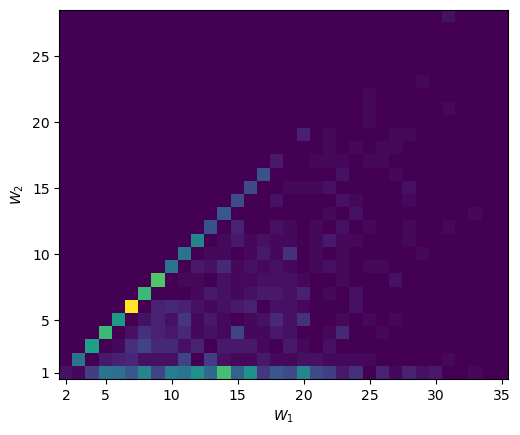

In [29]:
heatmap_matrix, x_edges, y_edges = np.histogram2d(windings +1, incident +1, bins = [np.arange(int(np.max(windings))+1), np.arange(int(np.max(incident))+1)])

fig, ax = plt.subplots();
ax.imshow(heatmap_matrix.T, cmap = "viridis", origin = "lower");
ax.set(xlabel=r"$W_1$", ylabel=r"$W_2$", xlim=[1.5,max(windings)-0.5], ylim=[0.5,max(incident)-0.5], xticks=[2,5,10,15,20,25,30,35], yticks=[1,5,10,15,20,25]);

Zdá se, že výsledná heatmapa (zvolil jsem cmap viridis, kde tmavě fialová jsou nejnižší hodnoty a žlutá nejvyšší) vykazuje zajímavé shody i odlišnosti oproti té z článku. Zde pro srovnání přikládám kopii obrázku z Guillochon et al. (2015):

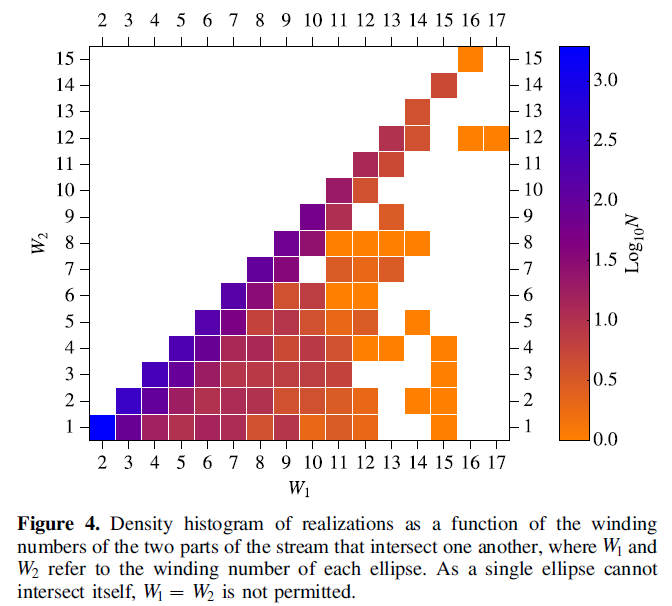

Konkrétně můžeme vidět, že nejvíce protnutí se u Guillochona objevuje hned mezi orbitami 1-2. Naše simulace také ukazuje "anomálii" ve smyslu zvýšeného množství protnutí s nultou orbitou (to jsou bloky podél osy x). Celkově se zdá, že pokud od těchto anomálií odhlédneme, je správně nejvyšší počet protnutí na "diagonále", stejně jako u Guillochona, což odpovídá protnutí dvou sousedních elips.

Pro úplnost přikládám histogram rozdělení počtu protnutí:

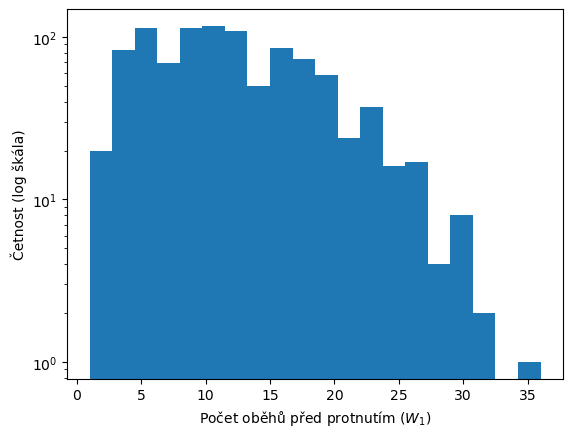

In [30]:
plot = plt.hist(windings, bins = "auto")
plt.yscale("log")
plt.xlabel(r"Počet oběhů před protnutím ($W_1$)")
plt.ylabel("Četnost (log škála)")
plt.show()